# 04 Simple GAN Experiment: Learning to Generate Two Moons

**Unit:** Unit 5: Introduction to Generative AI and Course Summary

**Why this notebook?** In example 02 we saw that a *generative* model learns the data
distribution P(X) itself, while a *discriminative* model only learns the boundary
P(Y|X). That raises an obvious practical question: how do you actually *train* a
network to generate realistic new samples when there is no "correct answer" to
compare each output against? A Generative Adversarial Network (GAN) solves this with
a trick: it uses a **discriminative model as the teacher** for a generative one. Here
we build the smallest GAN that shows the idea working — a generator that learns to
produce 2D points shaped like the classic "two moons" dataset — so you can watch the
adversarial game converge in a couple of seconds on a CPU.

## 📚 Learning Objectives

By completing this notebook, you will:
- See why a plain supervised loss (MSE) fails at generation — it collapses to the average
- Build a generator and a discriminator as tiny Keras `Dense` networks
- Train them with a custom adversarial training loop (~2000 steps)
- Read GAN loss curves and understand why neither loss goes to zero
- Check generation quality with simple honest metrics (nearest-neighbour distances, mode balance)

## 🔗 Prerequisites

- ✅ Example 02 (generative vs discriminative models)
- ✅ Basic Keras: `Dense` layers, optimizers, loss functions
- ✅ Basic NumPy and Matplotlib

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- A synthetic 2D "two moons" dataset (2,000 points from `sklearn.datasets.make_moons`) — no files needed
- TensorFlow/Keras for the generator, discriminator, and custom training loop

**Outputs:** What you'll see when you run the cells

- A scatter plot of the real two-moons distribution
- A baseline experiment: an MSE-trained generator that collapses to the data mean
- Training progress lines every 250 steps (losses + distance metrics)
- A final figure: a 3×3 grid of snapshots showing generated points converging onto
  the real distribution, plus the generator/discriminator loss curves
- A printed side-by-side comparison table: MSE baseline vs adversarial training

---

TensorFlow: 2.21.0 | Keras: 3.15.1
Real dataset: 2000 points, 2 features (all of it, no subsampling)
Per-axis mean: [-0. -0.] | per-axis std: [1. 1.]


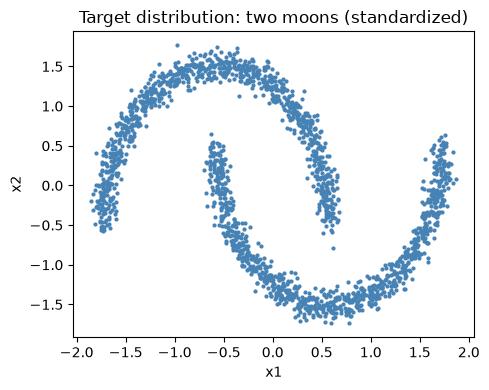

In [1]:
"""
Unit 5 - Example 4: Simple GAN Experiment (two moons)

Setup: imports, seeds, and the target distribution the generator must learn.
"""

import time
import numpy as np
import tensorflow as tf
import keras
from keras import layers
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

t_start = time.time()
print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)

SEED = 42
keras.utils.set_random_seed(SEED)  # seeds Python, NumPy and TensorFlow

# The real data distribution the generator must learn: two interleaved crescents.
N_REAL = 2000
X_raw, y_moon = make_moons(n_samples=N_REAL, noise=0.05, random_state=SEED)

# Standardize to zero mean / unit std so both networks see well-scaled inputs.
X_real = ((X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)).astype("float32")

print(f"Real dataset: {X_real.shape[0]} points, {X_real.shape[1]} features (all of it, no subsampling)")
print("Per-axis mean:", X_real.mean(axis=0).round(3), "| per-axis std:", X_real.std(axis=0).round(3))

plt.figure(figsize=(5, 4))
plt.scatter(X_real[:, 0], X_real[:, 1], s=4, c="steelblue")
plt.title("Target distribution: two moons (standardized)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.tight_layout()
plt.show()

## Honest measurement first

"The samples look right" is not a measurement. Before training anything we define
three cheap, printable metrics and use them for **every** experiment below:

- **gen→real distance** — average distance from each generated point to its nearest
  real point. Small = generated points sit *on* the data manifold (quality).
- **real→gen distance** — average distance from each real point to its nearest
  generated point. Small = the generator *covers* the whole distribution
  (this is the one that catches **mode collapse**: if the generator only produces
  one moon, real→gen stays large even when gen→real is small).
- **mode balance** — fraction of generated points whose nearest real neighbour
  belongs to moon 1. Both moons covered equally ≈ 0.50.

In [2]:
def nn_dist(A, B):
    """Average over rows of A of the distance to the nearest row of B."""
    d = np.sqrt(((A[:, None, :] - B[None, :, :]) ** 2).sum(axis=-1))
    return float(d.min(axis=1).mean())


def mode_balance(points):
    """Fraction of points whose nearest real neighbour is on moon 1 (label 1)."""
    d = np.sqrt(((points[:, None, :] - X_real[None, :, :]) ** 2).sum(axis=-1))
    return float(y_moon[d.argmin(axis=1)].mean())


def report(name, points):
    print(f"{name:<22} per-axis std {points.std(axis=0).round(2)}  "
          f"gen->real {nn_dist(points, X_real):.3f}  "
          f"real->gen {nn_dist(X_real, points):.3f}  "
          f"mode balance {mode_balance(points):.2f}")


LATENT = 8    # generator input: 8D Gaussian noise
HIDDEN = 64   # width of the two small hidden Dense layers in each network
BATCH = 128


def make_generator():
    """Noise z (8D) -> 2D point. Two small hidden Dense layers + linear output."""
    return keras.Sequential([
        layers.Input(shape=(LATENT,)),
        layers.Dense(HIDDEN, activation="relu"),
        layers.Dense(HIDDEN, activation="relu"),
        layers.Dense(2),
    ], name="generator")


# Sanity check the metrics on the real data itself: distances ~0, balance 0.50.
report("real data vs itself", X_real)

real data vs itself    per-axis std [1. 1.]  gen->real 0.000  real->gen 0.000  mode balance 0.50


## Baseline: the obvious idea, and why it fails

The obvious way to train a generator is supervised learning: sample noise `z`, pick a
random real point as the "target", and minimize the MSE between them. Every tool we
need is familiar from earlier units.

But think about what that loss asks for. Each noise vector gets paired with a
*different random* real point every step, so the best a deterministic network can do
is output something close to **all** targets at once — the **average** of the data.
The loss cannot reward variety; it rewards playing it safe. Let's confirm that
prediction by running it.

MSE baseline: 1000 steps in 0.5s, final MSE loss 0.976
MSE generator          per-axis std [0.05 0.04]  gen->real 0.363  real->gen 1.176  mode balance 0.24
real data vs itself    per-axis std [1. 1.]  gen->real 0.000  real->gen 0.000  mode balance 0.50


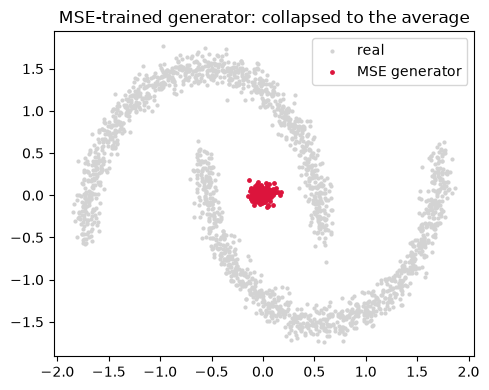

In [3]:
g_mse = make_generator()
mse_opt = keras.optimizers.Adam(1e-3)
rng = np.random.default_rng(SEED)


@tf.function
def mse_step(z, x_target):
    with tf.GradientTape() as tape:
        fake = g_mse(z, training=True)
        loss = tf.reduce_mean(tf.square(fake - x_target))
    grads = tape.gradient(loss, g_mse.trainable_variables)
    mse_opt.apply_gradients(zip(grads, g_mse.trainable_variables))
    return loss

t0 = time.time()
for step in range(1000):
    z = tf.random.normal((BATCH, LATENT))
    x_target = X_real[rng.integers(0, N_REAL, BATCH)]  # random pairing
    loss = mse_step(z, x_target)
print(f"MSE baseline: 1000 steps in {time.time() - t0:.1f}s, final MSE loss {float(loss):.3f}")

z_eval = tf.random.normal((500, LATENT), seed=7)
mse_points = g_mse(z_eval, training=False).numpy()
report("MSE generator", mse_points)
report("real data vs itself", X_real)

plt.figure(figsize=(5, 4))
plt.scatter(X_real[:, 0], X_real[:, 1], s=4, c="lightgray", label="real")
plt.scatter(mse_points[:, 0], mse_points[:, 1], s=6, c="crimson", label="MSE generator")
plt.title("MSE-trained generator: collapsed to the average")
plt.legend(); plt.tight_layout(); plt.show()

**Baseline conclusion (matches the printout above):** the MSE generator's per-axis
std is roughly 0.05 vs 1.0 for the real data, and the real→gen distance is large
(≈1.2) — every real point is far from the nearest generated one. The samples are a
tiny blob near the data mean: technically low loss, useless as generation.

## Change one thing: replace the fixed target with a learned judge

Keep the *exact same generator architecture*. The one thing we change is the training
signal: instead of "match this random point", the generator is scored by a second
network — a **discriminator** — that is itself being trained to tell real points from
generated ones. This is the adversarial game:

- The **discriminator** (a plain binary classifier, exactly the discriminative
  P(real | x) model from example 02) is trained to output "real" on data points and
  "fake" on generator outputs.
- The **generator** never sees real data directly. Its loss is simply "make the
  discriminator say *real*", and its gradients flow *through* the discriminator.

Counterfeiter vs. detective: as the detective gets sharper, the only way for the
counterfeiter to keep winning is to produce points that lie on the true distribution
— *everywhere* on it, because any under-covered region is an easy tell. That pressure
toward variety is exactly what MSE lacked.

Two standard stability tricks, honestly declared: `Adam(beta_1=0.5)` for both
networks, and label smoothing (real labels = 0.9) for the discriminator.

In [4]:
# Fresh seeds so this experiment does not depend on how many random draws
# the baseline consumed above.
keras.utils.set_random_seed(SEED)
rng_gan = np.random.default_rng(SEED)

generator = make_generator()
discriminator = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(HIDDEN, activation=layers.LeakyReLU(0.2)),
    layers.Dense(HIDDEN, activation=layers.LeakyReLU(0.2)),
    layers.Dense(1),  # logit: >0 means "looks real"
], name="discriminator")
print(f"generator params: {generator.count_params():,} | "
      f"discriminator params: {discriminator.count_params():,}")

g_opt = keras.optimizers.Adam(1e-3, beta_1=0.5)
d_opt = keras.optimizers.Adam(1e-3, beta_1=0.5)
bce = keras.losses.BinaryCrossentropy(from_logits=True)


@tf.function
def gan_step(x_real_batch):
    # --- 1) discriminator step: real -> 0.9 (label smoothing), fake -> 0
    z = tf.random.normal((BATCH, LATENT))
    with tf.GradientTape() as tape:
        fake = generator(z, training=True)
        real_logits = discriminator(x_real_batch, training=True)
        fake_logits = discriminator(fake, training=True)
        d_loss = (bce(tf.ones_like(real_logits) * 0.9, real_logits)
                  + bce(tf.zeros_like(fake_logits), fake_logits))
    d_grads = tape.gradient(d_loss, discriminator.trainable_variables)
    d_opt.apply_gradients(zip(d_grads, discriminator.trainable_variables))

    # --- 2) generator step: make the discriminator output "real" on fakes
    z = tf.random.normal((BATCH, LATENT))
    with tf.GradientTape() as tape:
        fake = generator(z, training=True)
        fake_logits = discriminator(fake, training=True)
        g_loss = bce(tf.ones_like(fake_logits), fake_logits)
    g_grads = tape.gradient(g_loss, generator.trainable_variables)
    g_opt.apply_gradients(zip(g_grads, generator.trainable_variables))
    return d_loss, g_loss


STEPS = 2000
SNAP_EVERY = 250
z_vis = tf.random.normal((500, LATENT), seed=7)  # fixed noise for all snapshots

d_hist, g_hist, snapshots = [], [], {}
t0 = time.time()
for step in range(STEPS + 1):
    if step % SNAP_EVERY == 0:
        pts = generator(z_vis, training=False).numpy()
        snapshots[step] = pts
        d_str = f"{d_hist[-1]:.3f}" if d_hist else "  -  "
        g_str = f"{g_hist[-1]:.3f}" if g_hist else "  -  "
        print(f"step {step:4d} | d_loss {d_str} g_loss {g_str} | "
              f"gen->real {nn_dist(pts, X_real):.3f}  real->gen {nn_dist(X_real, pts):.3f}  "
              f"balance {mode_balance(pts):.2f}")
    if step < STEPS:
        d_loss, g_loss = gan_step(X_real[rng_gan.integers(0, N_REAL, BATCH)])
        d_hist.append(float(d_loss)); g_hist.append(float(g_loss))

print(f"Adversarial training: {STEPS} steps in {time.time() - t0:.1f}s")

generator params: 4,866 | discriminator params: 4,417


step    0 | d_loss   -   g_loss   -   | gen->real 0.128  real->gen 0.874  balance 0.97


step  250 | d_loss 1.425 g_loss 0.794 | gen->real 0.358  real->gen 0.448  balance 0.74
step  500 | d_loss 1.301 g_loss 0.959 | gen->real 0.262  real->gen 0.429  balance 0.74


step  750 | d_loss 1.310 g_loss 0.937 | gen->real 0.264  real->gen 0.336  balance 0.24
step 1000 | d_loss 1.318 g_loss 0.917 | gen->real 0.255  real->gen 0.321  balance 0.74


step 1250 | d_loss 1.385 g_loss 0.823 | gen->real 0.240  real->gen 0.082  balance 0.46
step 1500 | d_loss 1.354 g_loss 0.810 | gen->real 0.171  real->gen 0.084  balance 0.49


step 1750 | d_loss 1.361 g_loss 0.809 | gen->real 0.112  real->gen 0.083  balance 0.48
step 2000 | d_loss 1.358 g_loss 0.814 | gen->real 0.073  real->gen 0.070  balance 0.49
Adversarial training: 2000 steps in 1.3s


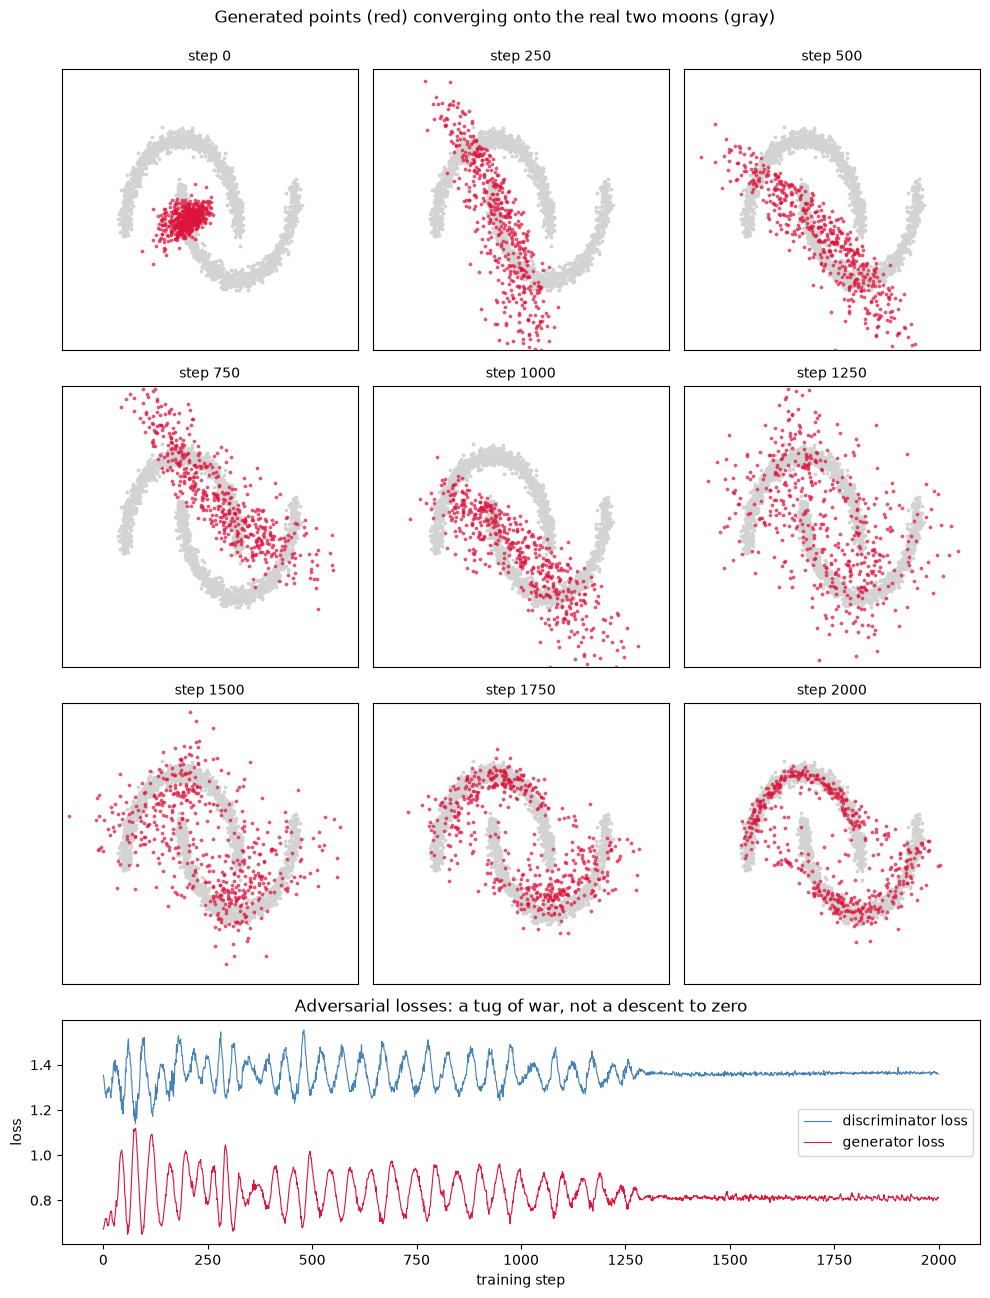

Mean d_loss over last 500 steps: 1.362
Mean g_loss over last 500 steps: 0.810


In [5]:
# Final figure: 3x3 grid of snapshots (top) + the two loss curves (bottom).
fig = plt.figure(figsize=(10, 13))
gs = fig.add_gridspec(4, 3, height_ratios=[1, 1, 1, 0.8])

for i, (step, pts) in enumerate(snapshots.items()):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    ax.scatter(X_real[:, 0], X_real[:, 1], s=3, c="lightgray")
    ax.scatter(pts[:, 0], pts[:, 1], s=3, c="crimson", alpha=0.6)
    ax.set_title(f"step {step}", fontsize=10)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_xticks([]); ax.set_yticks([])

ax = fig.add_subplot(gs[3, :])
ax.plot(d_hist, label="discriminator loss", color="steelblue", linewidth=0.8)
ax.plot(g_hist, label="generator loss", color="crimson", linewidth=0.8)
ax.set_xlabel("training step"); ax.set_ylabel("loss")
ax.set_title("Adversarial losses: a tug of war, not a descent to zero")
ax.legend()

fig.suptitle("Generated points (red) converging onto the real two moons (gray)",
             y=0.995)
plt.tight_layout()
plt.show()

print(f"Mean d_loss over last 500 steps: {np.mean(d_hist[-500:]):.3f}")
print(f"Mean g_loss over last 500 steps: {np.mean(g_hist[-500:]):.3f}")

In [6]:
# Side-by-side comparison: same generator architecture, different training signal.
gan_points = snapshots[STEPS]

print("Same generator architecture, one change (the training signal):\n")
report("real data (reference)", X_real)
report("MSE baseline", mse_points)
report("GAN, step 0", snapshots[0])
report(f"GAN, step {STEPS}", gan_points)

print(f"\nTotal notebook runtime so far: {time.time() - t_start:.1f}s")

Same generator architecture, one change (the training signal):

real data (reference)  per-axis std [1. 1.]  gen->real 0.000  real->gen 0.000  mode balance 0.50
MSE baseline           per-axis std [0.05 0.04]  gen->real 0.363  real->gen 1.176  mode balance 0.24
GAN, step 0            per-axis std [0.25 0.22]  gen->real 0.128  real->gen 0.874  mode balance 0.97
GAN, step 2000         per-axis std [1.   1.01]  gen->real 0.073  real->gen 0.070  mode balance 0.49

Total notebook runtime so far: 2.5s


## What the outputs show

Reading the comparison table and the figure together (all numbers are printed above):

1. **MSE collapses, the GAN does not.** The MSE generator's per-axis std is ≈0.05 and
   its real→gen distance is ≈1.18 — a blob at the mean. After 2000 adversarial steps
   the generator's per-axis std is ≈1.0 (matching the real data) and real→gen drops
   to ≈0.07: essentially every real point now has a generated point right next to it.
   Same architecture — the *only* change was who provides the training signal.
2. **The snapshots tell the convergence story.** Step 0 is an untrained blob; the
   middle panels wander and overshoot while the two networks push each other around;
   by steps 1750–2000 the red points visibly trace both crescents.
3. **Both moons are covered.** Mode balance ends near 0.50, so the generator did not
   collapse onto a single moon — the failure mode the real→gen metric was built
   to catch.
4. **The loss curves are a tug of war.** Neither loss decreases to zero the way a
   classifier's loss did in example 03. They oscillate strongly for the first ~1300
   steps, then settle around an equilibrium (mean over the last 500 steps: d_loss
   ≈1.36, g_loss ≈0.81), because each network's improvement *is* the other network's
   loss increase. For GANs, sample quality — not the loss value — is the success
   measure.

## Tie-back to this unit

- Example 02 said: discriminative models learn P(Y|X), generative models learn P(X).
  A GAN is the two ideas welded together — a *discriminative* network (the
  discriminator is literally a binary classifier) is used as a **learned, moving
  loss function** to train a *generative* network.
- The generator never sees a real data point. Everything it knows about the two
  moons arrives as gradients through the discriminator.

## Honest limitations

- This is a 2D toy: both networks are two small hidden `Dense` layers, and training
  takes seconds. Real GANs (images, audio) need convolutional architectures, far more
  compute, and much more careful tuning.
- GAN training is famously sensitive: with a different seed or learning rate this
  same code can mode-collapse or oscillate without converging. The metrics we printed
  (real→gen distance, mode balance) are exactly the kind of check you would use to
  detect that.
- Modern image generators are mostly diffusion models rather than GANs, but the core
  lesson — train a generator with a learned signal instead of a fixed per-sample
  target — carries over.